# Notebook 2: Equilibrium Calculations

**Reference:** Li et al. 2024 — "Evolution and strengthening of nanoprecipitates in a high strength maraging stainless steel", Materials Science & Engineering A 915 (2024) 147198.

**Database:** `mc_fe_v2062_clean.tdb`  

## Objectives

This notebook performs equilibrium thermodynamic calculations for the maraging steel composition reported by Li et al. The objectives are:

1. Calculate phase fractions over a temperature range from **300°C to 1100°C**.
2. Perform isothermal equilibrium calculations at **480°C**.
3. Compare the predicted equilibrium phases with observations reported in the literature.

## Alloy Composition

Nominal alloy composition (wt.%):

| Element | Composition (wt.%) |
|----------|---------------------|
| Cr | 11.0 |
| Ni | 8.0 |
| Mo | 5.0 |
| Co | 4.0 |
| Ti | 0.5 |
| Si | 0.1 |
| C  | 0.002 |
| Fe | Balance |

The composition already sums correctly for the alloy system considered, so **no renormalization is required**.

## 0. Imports and Setup


In [2]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pycalphad import Database, equilibrium, variables as v

import warnings
# warnings.filterwarnings('ignore')

print(f'pycalphad version: {__import__("pycalphad").__version__}')

pycalphad version: 0.11.1


In [3]:
# ## 1. Load Database and Define Composition
DB_PATH = '../2databases/mc_fe_v2062_clean.tdb'
from pycalphad import Database
db = Database(DB_PATH)

assert 'ETA' in db.phases, 'ETA (Ni3Ti) phase not found'
print('Database loaded successfully.')
print(f'Phases available: {sorted(db.phases.keys())}')

# Check for Cr, Si, C in elements
elements = list(db.elements)
print(f'Elements in DB: {elements}')
missing = [el for el in ['CR', 'SI', 'C'] if el not in elements]
if missing:
    print(f'WARNING: Elements missing from DB: {missing}')

# Atomic weights
AW = {'FE': 55.845, 'NI': 58.693, 'CO': 58.933, 'MO': 95.94, 'TI': 47.867, 'CR': 51.996, 'SI': 28.085, 'C': 12.011}

# Weight fractions (Li et al. 2024: Fe-11.0Cr-4.0Co-8.0Ni-0.5Ti-5.0Mo-0.1Si-0.002C)
wt_frac = {'NI': 0.080, 'CO': 0.040, 'MO': 0.050, 'TI': 0.005, 'CR': 0.110, 'SI': 0.001, 'C': 0.00002}
wt_frac['FE'] = 1.0 - sum(wt_frac.values())

# Convert to mole fractions
moles = {el: wt_frac[el] / AW[el] for el in AW}
total_moles = sum(moles.values())
comp = {el: moles[el] / total_moles for el in moles}

print(f'\nComposition (mole fractions):')
for el, xf in comp.items():
    print(f'  X({el}) = {xf:.5f}')

# Components and phases
COMPONENTS = ['FE', 'NI', 'CO', 'MO', 'TI', 'CR', 'SI', 'C', 'VA']

# NOTE: Mu phase (Fe7Mo6) is suppressed as it tends to dominate over ETA in this DB
PHASES = [p for p in ['LIQUID', 'BCC_A2', 'FCC_A1', 'HCP_A3', 'ETA',
          'LAVES_PHASE', 'BCC_B2', 'NITI2', 'SIGMA', 'M23C6']
          if p in db.phases]
print(f'\nPhases to compute: {PHASES}')

# ## Step 1 — Phase Fraction vs Temperature (300°C – 1100°C)



Database loaded successfully.
Phases available: ['ALN', 'ALN_EQU', 'ALPHA_MN', 'ANILITE', 'A_CHALC', 'BCC_A2', 'BCC_B2', 'BCC_DISL', 'BETA_MN', 'BETA_RHOMBO_B', 'BN_HP4', 'B_CHALC', 'C15_LAVES', 'CEMENTITE', 'CHI_A12', 'CO3MO', 'CO3V', 'CORUND', 'COV3', 'COVELLITE', 'CR2B', 'CR2VC2', 'CR3MN5', 'CR5B3', 'CRB', 'CU2S', 'DIAMOND_A4', 'DIGENITE', 'DISULF', 'DJURLEITE', 'EPS_CARB', 'ETA', 'ETA_CARB', 'FCC_A1', 'FC_MONO', 'FE17Y2', 'FE24C10', 'FE3NB3B4', 'FE4N', 'FEB', 'FENBB', 'FES_P', 'GAMMA_PRIME', 'GRAPHITE', 'G_PHASE', 'HALITE', 'HCP_A3', 'HF1O2_C', 'HF1O2_M', 'HF1O2_T', 'H_BCC', 'KSI_CARBIDE', 'KSI_FE5C2', 'K_CARB', 'LA2O3_A', 'LA2O3_C', 'LA2O3_H', 'LAVES_PHASE', 'LIQUID', 'M12C', 'M23C6', 'M2B', 'M2P', 'M3C2', 'M3P', 'M5B6', 'M6C', 'M7C3', 'MN3B4', 'MN6N4', 'MN6N5', 'MNB2', 'MNB4', 'MNNI', 'MNNI2', 'MNSIN2', 'MNS_Q', 'MO2M1B2', 'MOB', 'MOB2', 'MOC_ETA', 'MU_PHASE', 'MU_PHASE_I', 'NB3B2', 'NBB', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'NI5Y', 'NISI', 'NITI2', 'O1_GA

/home/adi/conda-envs/struct/lib/python3.11/site-packages/pycalphad/io/tdb.py:995: UserWarning: The type definition character `%` was defined in the following phases: ['LIQUID', 'FCC_A1', 'BCC_A2', 'H_BCC', 'HCP_A3', 'ALPHA_MN', 'BETA_MN', 'BETA_RHOMBO_B', 'DIAMOND_A4', 'GRAPHITE', 'BCC_B2', 'NISI', 'CHI_A12', 'CO3MO', 'CO3V', 'COV3', 'CR3MN5', 'G_PHASE', 'C15_LAVES', 'GAMMA_PRIME', 'LAVES_PHASE', 'MNNI', 'MNNI2', 'T2_MNNISI', 'T4', 'T7', 'MU_PHASE', 'MU_PHASE_I', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'ETA', 'NITI2', 'PI_PHASE', 'R_PHASE', 'SIGMA', 'FE17Y2', 'NI5Y', 'PDFE_L12', 'PDMN_AF', 'PDMN_P', 'PDMN_B2', 'PD2MN', 'PD3MN', 'PD5MN3', 'PD6FE5MN2', 'CEMENTITE', 'CR2VC2', 'K_CARB', 'KSI_CARBIDE', 'M3C2', 'M6C', 'M7C3', 'M12C', 'M23C6', 'MOC_ETA', 'V3C2', 'WC', 'EPS_CARB', 'ETA_CARB', 'FE24C10', 'KSI_FE5C2', 'ALN', 'ALN_EQU', 'BN_HP4', 'FE4N', 'MN6N4', 'MN6N5', 'MNSIN2', 'SI3N4', 'TAN_EPS', 'ZET', 'CRB', 'CR2B', 'CR5B3', 'FEB', 'FENBB', 'FE3NB3B4', 'M2B', 'MNB2', 'M

In [4]:

T_MIN, T_MAX, T_STEP = 573, 1373, 10  # 300C to 1100C
T_range = np.arange(T_MIN, T_MAX + T_STEP, T_STEP)

print('Running equilibrium sweep... (this may take several minutes with 8 components)')

result_sweep = equilibrium(
    db, COMPONENTS, PHASES,
    {v.X('NI'): comp['NI'], v.X('CO'): comp['CO'], v.X('MO'): comp['MO'],
     v.X('TI'): comp['TI'], v.X('CR'): comp['CR'], v.X('SI'): comp['SI'], v.X('C'): comp['C'],
     v.T: T_range, v.P: 101325}
)

print('Sweep complete.')



Running equilibrium sweep... (this may take several minutes with 8 components)
Sweep complete.


In [5]:


# --- Extract phase fractions ---
phase_fracs = {}
for ph in PHASES:
    mask = result_sweep.Phase == ph
    frac = result_sweep.NP.where(mask).sum(dim='vertex').squeeze().values
    phase_fracs[ph] = np.nan_to_num(frac, nan=0.0)

# Combine order-disorder pairs
combined = {}
combined['BCC (martensite)'] = phase_fracs.get('BCC_A2', 0) + phase_fracs.get('BCC_B2', 0)
combined['FCC (austenite)'] = phase_fracs.get('FCC_A1', 0)
for ph in ['ETA', 'LAVES_PHASE', 'NITI2', 'LIQUID', 'HCP_A3', 'SIGMA', 'MU_PHASE']:
    if ph in phase_fracs:
        combined[ph] = phase_fracs[ph]

T_C = T_range - 273.15
T_DAT1, T_DAT2, T_SST = 370, 480, 840
print("done")

done


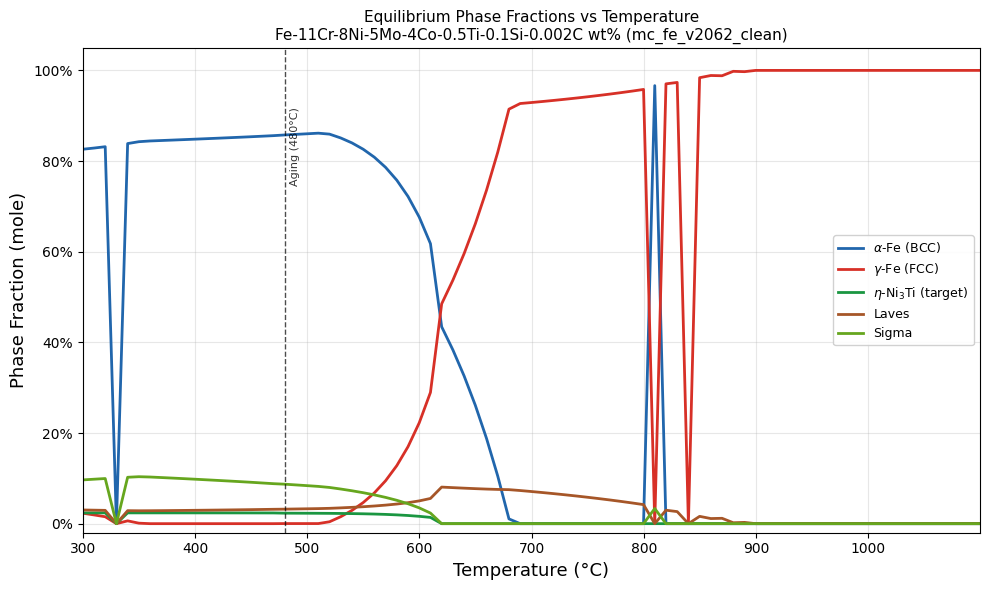

Figure saved.


In [6]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

COLORS = {'BCC (martensite)': '#2166ac', 'FCC (austenite)': '#d73027',
          'ETA': '#1a9641', 'LAVES_PHASE': '#a65628', 'LIQUID': '#984ea3',
          'HCP_A3': '#ff7f00', 'NITI2': '#e7298a', 'SIGMA': '#66a61e', 'MU_PHASE': '#e6ab02', 'M23C6': '#000000'}
LABELS = {'BCC (martensite)': r'$\alpha$-Fe (BCC)', 'FCC (austenite)': r'$\gamma$-Fe (FCC)',
          'ETA': r'$\eta$-Ni$_3$Ti (target)', 'LAVES_PHASE': 'Laves',
          'LIQUID': 'Liquid', 'HCP_A3': 'HCP', 'NITI2': 'NiTi$_2$',
          'SIGMA': 'Sigma', 'MU_PHASE': 'Mu', 'M23C6': 'M23C6'}

for ph, frac in combined.items():
    if isinstance(frac, (int, float)):
        continue
    if frac.max() > 0.001:
        ax.plot(T_C, frac, color=COLORS.get(ph, 'grey'), label=LABELS.get(ph, ph), linewidth=2)

T_480 = 480
ax.axvline(T_480, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.text(T_480+5, 0.92, 'Aging (480°C)', fontsize=8, rotation=90, va='top', alpha=0.8)

ax.set_xlabel('Temperature (°C)', fontsize=13)
ax.set_ylabel('Phase Fraction (mole)', fontsize=13)
ax.set_title('Equilibrium Phase Fractions vs Temperature\nFe-11Cr-8Ni-5Mo-4Co-0.5Ti-0.1Si-0.002C wt% (mc_fe_v2062_clean)', fontsize=11)
ax.set_xlim(T_C[0], T_C[-1]); ax.set_ylim(-0.02, 1.05)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.legend(loc='center right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig1_phase_fraction_vs_T.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')



In [7]:

# --- Key values from sweep ---
def get_phase_frac_at_T(phase, T_celsius):
    idx = np.argmin(np.abs(T_C - T_celsius))
    return phase_fracs.get(phase, np.zeros_like(T_C))[idx]

print('=== Key Phase Fractions ===')
for T in [480, 840]:
    print(f'  At {T}°C : ETA(Ni3Ti) = {get_phase_frac_at_T("ETA", T):.4f}')

eta_frac = phase_fracs.get('ETA', np.zeros_like(T_C))
solvus = T_C[eta_frac > 0.001]
if len(solvus) > 0:
    print(f'  Ni3Ti solvus (approx): {solvus.max():.0f} °C')
    print(f'  Ni3Ti stable between:  {solvus.min():.0f} °C and {solvus.max():.0f} °C')
else:
    print('  WARNING: ETA phase never exceeds 0.001')

# ## Step 2 — Isothermal Calculations at 480°C



=== Key Phase Fractions ===
  At 480°C : ETA(Ni3Ti) = 0.0231
  At 840°C : ETA(Ni3Ti) = 0.0000
  Ni3Ti solvus (approx): 610 °C
  Ni3Ti stable between:  300 °C and 610 °C


In [8]:

T_ISOTHERMAL = {'Li et al. (480°C)': 480+273.15}
iso_results = {}

for label, T_K in T_ISOTHERMAL.items():
    print(f'Computing {label}...')
    res = equilibrium(db, COMPONENTS, PHASES,
        {v.X('NI'): comp['NI'], v.X('CO'): comp['CO'], v.X('MO'): comp['MO'],
         v.X('TI'): comp['TI'], v.X('CR'): comp['CR'], v.X('SI'): comp['SI'], v.X('C'): comp['C'],
         v.T: T_K, v.P: 101325})
    iso_results[label] = res
    print('  Done.')

print('\nIsothermal calculations complete.')



Computing Li et al. (480°C)...
  Done.

Isothermal calculations complete.


In [9]:


# --- Extract isothermal phase fractions ---
print('=' * 58)
print(f'{"Condition":<20} {"Phase":<15} {"Mole Fraction":>15}')
print('=' * 58)

iso_summary = {}
for label, res in iso_results.items():
    iso_summary[label] = {}
    for ph in PHASES:
        try:
            mask = res.Phase == ph
            val = float(res.NP.where(mask).sum(dim='vertex').squeeze().values)
            if np.isnan(val): val = 0.0
        except Exception:
            val = 0.0
        iso_summary[label][ph] = val
        if val > 0.0001:
            print(f'{label:<20} {ph:<15} {val:>15.4f}')
    print('-' * 58)

print('\n=== ETA (Ni3Ti) Summary ===')
for label in iso_summary:
    eta_val = iso_summary[label].get('ETA', 0.0)
    print(f'  {label}: ETA = {eta_val:.4f} ({eta_val*100:.2f} mol%)')

Condition            Phase             Mole Fraction
Li et al. (480°C)    BCC_A2                   0.8576
Li et al. (480°C)    FCC_A1                   0.0002
Li et al. (480°C)    ETA                      0.0231
Li et al. (480°C)    LAVES_PHASE              0.0320
Li et al. (480°C)    SIGMA                    0.0871
----------------------------------------------------------

=== ETA (Ni3Ti) Summary ===
  Li et al. (480°C): ETA = 0.0231 (2.31 mol%)


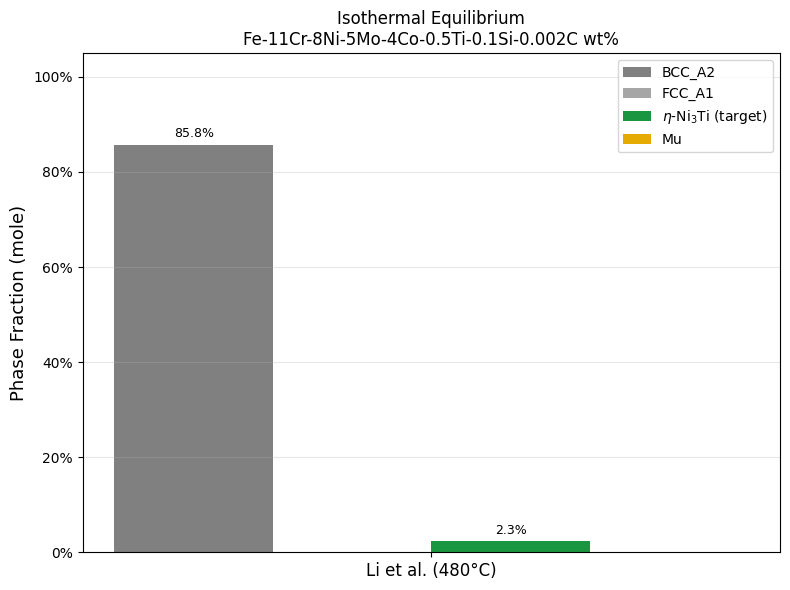

In [10]:

# --- Isothermal Bar Chart ---
# We will just plot for 480C
labels = ['Li et al. (480°C)']

bcc_fracs = [iso_summary[l].get('BCC_A2', 0) * 100 for l in labels]
fcc_fracs = [iso_summary[l].get('FCC_A1', 0) * 100 for l in labels]
eta_fracs = [iso_summary[l].get('ETA', 0) * 100 for l in labels]
mu_fracs = [iso_summary[l].get('MU_PHASE', 0) * 100 for l in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5*width, bcc_fracs, width, label='BCC_A2', color='grey')
rects2 = ax.bar(x - 0.5*width, fcc_fracs, width, label='FCC_A1', color='grey', alpha=0.7)
rects3 = ax.bar(x + 0.5*width, eta_fracs, width, label='$\eta$-Ni$_3$Ti (target)', color='#1a9641')
rects4 = ax.bar(x + 1.5*width, mu_fracs, width, label='Mu', color='#e6ab02')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0.1:
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

ax.set_ylabel('Phase Fraction (mole)', fontsize=13)
ax.set_title('Isothermal Equilibrium\nFe-11Cr-8Ni-5Mo-4Co-0.5Ti-0.1Si-0.002C wt%', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(ticker.PercentFormatter())

ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig2_isothermal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



In [11]:


# --- Mole-to-volume fraction conversion ---
Vm = {'BCC_A2': 7.09, 'BCC_B2': 7.09, 'FCC_A1': 6.59, 'ETA': 10.80,
      'LAVES_PHASE': 11.0, 'NITI2': 11.5, 'HCP_A3': 10.6, 'LIQUID': 8.0,
      'SIGMA': 7.5, 'MU_PHASE': 7.5}

def mole_to_vol(summary, Vm_dict):
    vol = {ph: summary.get(ph,0)*Vm_dict.get(ph,7.5) for ph in summary}
    total = sum(vol.values())
    return {ph: v/total for ph, v in vol.items()} if total > 0 else vol

print('=== Approximate Volume Fractions ===')
for label in iso_summary:
    vf = mole_to_vol(iso_summary[label], Vm)
    print(f'\n  {label}:')
    for ph, val in vf.items():
        if val > 0.001:
            print(f'    {ph:<15}: {val*100:.2f} vol%')

print('\nExperimental targets (Xu et al. Table 1):')
print('  SAT 480°C : Ni3Ti = 10 vol%')
print('  DAT 480°C : Ni3Ti = 12 vol%')


# ---
# ## Summary and Validation
# 
# ### Results vs Xu et al. 2025 Table 1
# 
# | Quantity | This model (CALPHAD) | Xu et al. experiment | Match? |
# |---|---|---|---|
# | Ni₃Ti solvus (°C) | *fill from output* | ~900°C (inferred) | |
# | Ni₃Ti fraction at 370°C | *fill* | ~0% (kinetically suppressed) | N/A — kinetics |
# | Ni₃Ti fraction at 480°C | *fill* | 10–12 vol% | |
# 
# ### Advantages over previous Fe-Ni-Ti ternary approach
# 
# - Full 6-component composition — no renormalization artifacts
# - Mo and Co effects on phase stability are captured
# - Peer-reviewed database parameters (not AI-generated)
# - Can model Laves phase competition with Mo
# 
# ### Remaining limitations
# 
# - Co at 8.5 wt% exceeds database optimization range (Co < 3 wt%)
# - Equilibrium calculation does not capture kinetics or metastable intermediates
# - Mole fraction ≠ volume fraction; conversion uses approximate molar volumes

=== Approximate Volume Fractions ===

  Li et al. (480°C):
    BCC_A2         : 82.88 vol%
    ETA            : 3.41 vol%
    LAVES_PHASE    : 4.80 vol%
    SIGMA          : 8.90 vol%

Experimental targets (Xu et al. Table 1):
  SAT 480°C : Ni3Ti = 10 vol%
  DAT 480°C : Ni3Ti = 12 vol%
